In [130]:
import numpy as np
import pandas as pd
import yfinance as yf
import ta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from sklearn.preprocessing import RobustScaler
import joblib
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Configurations ─────────

In [131]:
TICKER = "AAPL"
 
PERIOD    = "16y"
TRAIN_PCT = 0.8     # 80% train, 20% test


W = 90      # lookback window (hyperparameter, tune later)
FEATURES = [       # the 10 features — input to the LSTM
    "return",
    "lag1",
    "lag5",
    "lag10",
    "ma10",
    "ma50",
    'price_vs_ma50',
    'high_low_range',
    "volatility5",
    "volatility10",
    "volatility20",
    "volatility60",
    'vol_ratio',
    "rsi",
    "macd",
    'volume_change',
    "volume_ratio"
]
TARGET = "volatility20"   # what we predict

# ── Feature engineering ─────────

In [132]:
def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Takes a raw OHLCV dataframe from yfinance and returns
    a clean dataframe with all 10 features + target.
    """
    out = pd.DataFrame(index=df.index)
 
    # 1. log return
    out["return"]   = df["Close"].pct_change()
 
    # 2. lag1 — return of yesterday
    out["lag1"]         = out["return"].shift(1)
 
    # 3. lag5 — return of exactly 5 days ago
    out["lag5"]         = out["return"].shift(5)

    out["lag10"]         = out["return"].shift(10)
    
    # 4. ma10 — 10-day moving average of price
    out["ma10"]         = df["Close"].rolling(10).mean()
 
    # 5. ma50 — 50-day moving average of price
    out["ma50"]         = df["Close"].rolling(50).mean()

    out['price_vs_ma50'] = (df['Close'] - out['ma50']) / out['ma50']

    out['high_low_range'] = (df['High'] - df['Low']) / df['Close']

    out["volatility5"] = out["return"].rolling(5).std()

    out["volatility10"] = out["return"].rolling(10).std()
 
    # 6. volatility20 — 20-day rolling std of log returns
    out["volatility20"] = out["return"].rolling(20).std()

    out["volatility60"] = out["return"].rolling(60).std()

    out['vol_ratio'] = out['volatility5'] / out['volatility20']
 
    # 8. rsi — relative strength index (14 days)
    out["rsi"]          = ta.momentum.RSIIndicator(df["Close"], window=14).rsi()
 
    # 9. macd — EMA(12) - EMA(26)
    out["macd"] = ta.trend.MACD(df["Close"]).macd()

    out['volume_change'] = df['Volume'].pct_change()
 
    # 10. volume_ratio — today's volume / 20-day average volume
    out["volume_ratio"] = df["Volume"] / df["Volume"].rolling(20).mean()
 
    # drop any rows with NaN (warmup period)
    out = out.dropna()
 
    return out

In [191]:
len(FEATURES)

17

# ── Download and process all tickers ─────────

In [133]:
def load_ticker(ticker: str, period: str) -> pd.DataFrame:
    """
    Downloads raw data and computes features for each ticker.
    Returns a dict of {ticker: feature_dataframe}.
    """
    print(f"Downloading {ticker}...", end=" ")
 
    raw = yf.download(ticker, period=period, auto_adjust=True, progress=True)
    raw.columns = raw.columns.get_level_values(0)   # flatten MultiIndex
 
    # forward fill any missing days (trading halts etc.)
    raw = raw.ffill()
 
    df = compute_features(raw)
 
    return df

In [134]:
data = load_ticker(TICKER, PERIOD)

[*********************100%***********************]  1 of 1 completed


# ── Train / test split ─────────

In [135]:
def split_data(data: pd.DataFrame, train_pct: float) -> tuple:
    """
    Splits each ticker's dataframe chronologically into train and test.
    Returns two dicts: train_data and test_data.
    """
    split = int(len(data) * train_pct)
    train_data = data.iloc[:split]
    test_data = data.iloc[split:]
 
    print(f"train={len(train_data)} rows, "
        f"test={len(test_data)} rows, "
        f"split date={data.index[split].date()}")
        
 
    return train_data, test_data

In [136]:
train_data, test_data = split_data(data, TRAIN_PCT)

train=3172 rows, test=793 rows, split date=2023-02-03


# ── Visualization ─────────

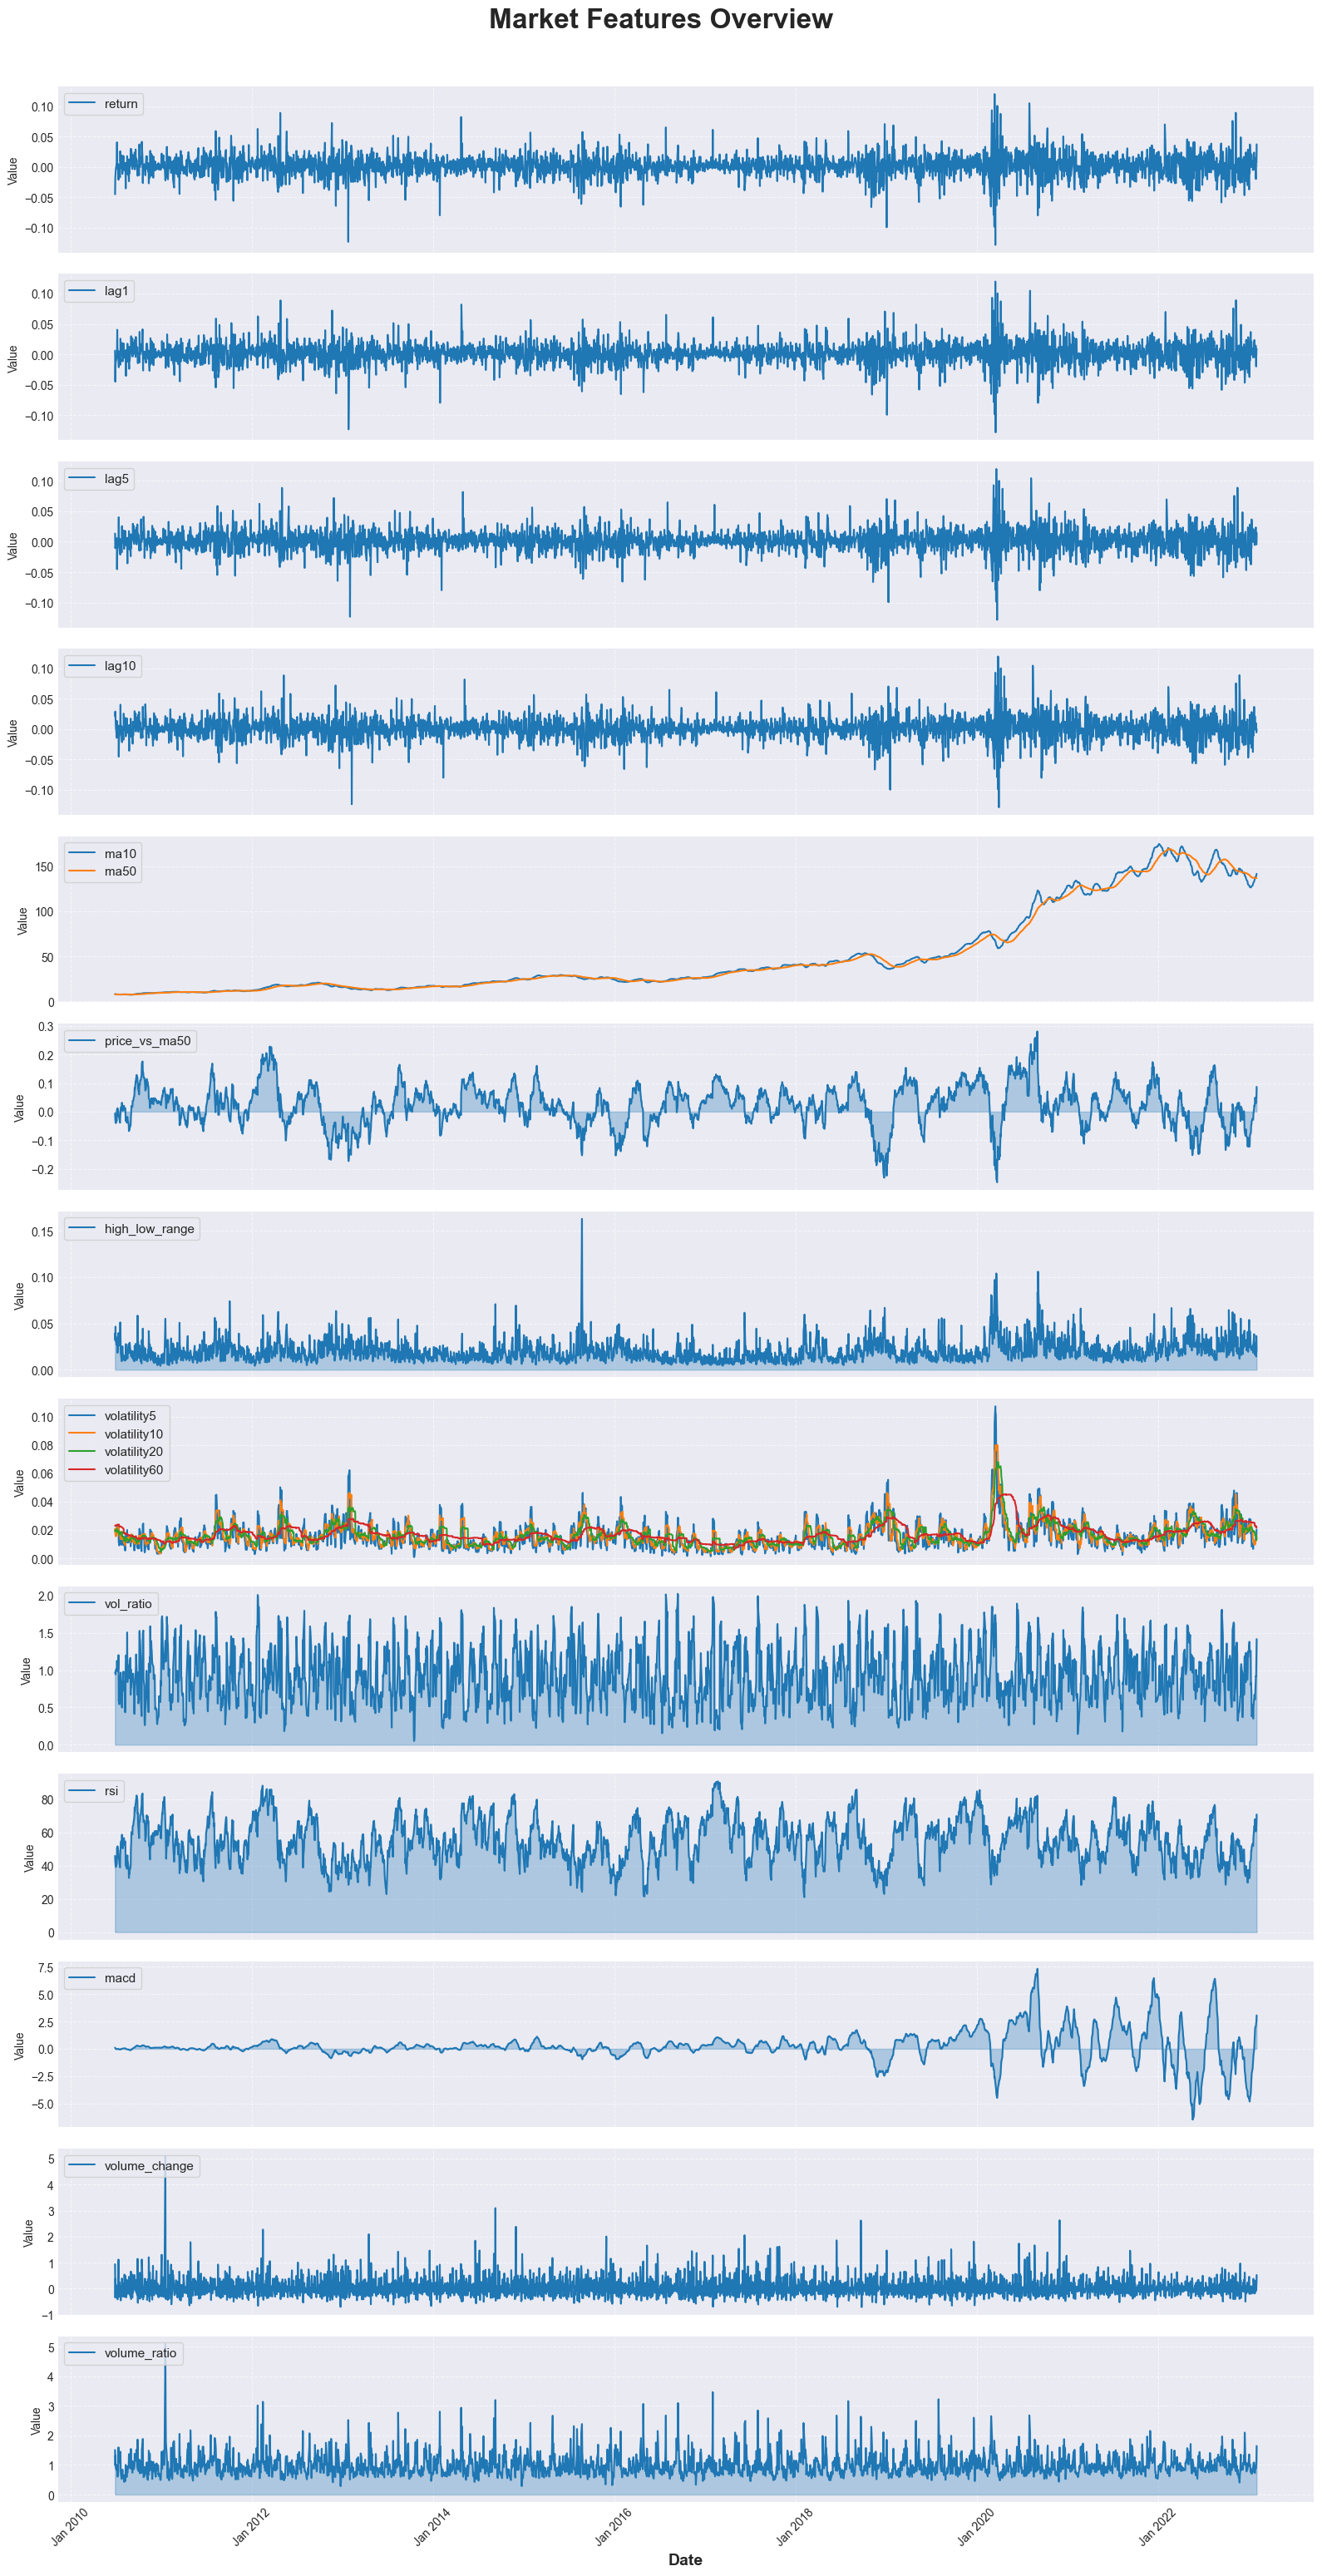

In [137]:
train_data.index = pd.to_datetime(train_data.index)

plot_groups = [
    ["return"],
    ["lag1"],
    ["lag5"],
    ["lag10"],
    ["ma10", "ma50"], 
    ['price_vs_ma50'],
    ['high_low_range'],
    ["volatility5", "volatility10", "volatility20", "volatility60"], 
    ['vol_ratio'],
    ["rsi"],
    ["macd"],
    ['volume_change'],
    ["volume_ratio"]
]

# Visualization Setup
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(nrows=13, ncols=1, figsize=(16, 34), sharex=True)
fig.suptitle('Market Features Overview', fontsize=24, fontweight='bold', y=0.91)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Plotting Loop
for i, (ax, group) in enumerate(zip(axes, plot_groups)):
    for j, feature in enumerate(group):
        color = colors[j % len(colors)]
        
        if len(group) == 1:
            ax.fill_between(train_data.index, train_data[feature], alpha=0.3, color=color)
            
        ax.plot(train_data.index, train_data[feature], label=feature, color=color, linewidth=1.5)
    
    ax.legend(loc='upper left', frameon=True, fontsize=11)
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# --- FIX 2: Force Matplotlib to limit the number of X-axis ticks ---
axes[-1].set_xlabel('Date', fontsize=14, fontweight='bold')

# Automatically pick the best dates to show, keeping it to around 10 max
locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
axes[-1].xaxis.set_major_locator(locator)

# Format them nicely (e.g., 'Jan 2023')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

# ── Sliding window ─────────
it's making the instances

In [138]:
def make_windows(df: pd.DataFrame, W: int) -> tuple:
    """
    Converts a feature dataframe into sliding window instances.
 
    For each position i, we take:
        X = features of days [i → i+W-1]   shape: (W, n_features)
        y = target of day    [i+W]          shape: (1,)
 
    Returns:
        X: np.array of shape (n_instances, W, n_features)
        y: np.array of shape (n_instances,)
    """
    feature_vals = df[FEATURES].values   # shape: (n_days, n_features)
    target_vals  = df[TARGET].values     # shape: (n_days,)
 
    X, y = [], []
 
    for i in range(len(df) - W):
        X.append(feature_vals[i : i + W])   # W days of features
        y.append(target_vals[i + W])         # next day's target

    print(f'number of instances : {len(y)}')
 
    return np.array(X), np.array(y)

# ── fitting the Scaler ─────────

In [139]:
def fit_scaler(X_train: np.ndarray) -> RobustScaler:
    """
    Fits a RobustScaler on the training data only.
 
    X_train shape: (n_instances, W, n_features)
    We reshape to (n_instances * W, n_features) to fit the scaler,
    then reshape back.
    """

    _, _, n_features = X_train.shape
 
    # flatten instances and timesteps into one dimension
    X_flat = X_train.reshape(-1, n_features)
 
    scaler = RobustScaler()
    scaler.fit(X_flat)
 
    return scaler

# ── Scaling ─────────

In [140]:
def apply_scaler(X: np.ndarray, scaler: RobustScaler) -> np.ndarray:
    """
    Applies a fitted scaler to X.
    Handles the reshape automatically.
    """
    n_instances, w, n_features = X.shape
    X_flat   = X.reshape(-1, n_features)
    X_scaled = scaler.transform(X_flat)
    return X_scaled.reshape(n_instances, w, n_features)

In [141]:
X_train, y_train = make_windows(train_data, W)

number of instances : 3082


In [142]:
y_train

array([0.01399989, 0.01382957, 0.01383035, ..., 0.01625361, 0.01275787,
       0.01435439], shape=(3082,))

In [143]:
X_train.shape

(3082, 90, 17)

In [144]:
y_train.shape

(3082,)

In [145]:
X_train[0]

array([[-4.52106155e-02,  5.99936069e-03,  1.36210458e-02, ...,
         1.06037359e-01,  9.37513762e-01,  1.50757576e+00],
       [-1.81128136e-02, -4.52106155e-02, -1.05169076e-02, ...,
         6.68819058e-02, -3.47548954e-01,  9.80300449e-01],
       [-1.21259930e-02, -1.81128136e-02, -7.27048014e-03, ...,
         2.81521026e-02,  3.83316294e-01,  1.32336451e+00],
       ...,
       [ 1.06317054e-02, -1.39561510e-02,  4.45578946e-03, ...,
         1.93456343e-01, -1.53817136e-02,  7.19980311e-01],
       [ 1.70294160e-02,  1.06317054e-02, -2.55769051e-03, ...,
         1.89970304e-01,  2.36873221e-02,  7.41318123e-01],
       [ 1.11200815e-02,  1.70294160e-02, -7.14472654e-04, ...,
         1.93296758e-01,  1.71498629e-01,  8.80679055e-01]],
      shape=(90, 17))

In [146]:
y_train[0]

np.float64(0.013999892423781747)

In [147]:
scaler = fit_scaler(X_train)

In [ ]:
# os.makedirs("models", exist_ok=True)
# joblib.dump(scaler, f"scaler.pkl")

Scaler saved to models/scaler.pkl


In [149]:
X_train_scaled = apply_scaler(X_train, scaler)

In [150]:
X_train_scaled.shape

(3082, 90, 17)

In [151]:
X_train_scaled[0]

array([[-2.55720076,  0.28354821,  0.70673973, ..., -0.10025366,
         2.4780312 ,  1.56304935],
       [-1.05401605, -2.55720076, -0.63300726, ..., -0.15026461,
        -0.85007819,  0.17428757],
       [-0.72191173, -1.05401605, -0.45281835, ..., -0.19973191,
         1.04274732,  1.07786536],
       ...,
       [ 0.54051628, -0.8234353 ,  0.19803361, ...,  0.01140146,
         0.01018248, -0.51135549],
       [ 0.89541373,  0.54051628, -0.19124085, ...,  0.00694895,
         0.11136511, -0.45515499],
       [ 0.56760776,  0.89541373, -0.08893534, ...,  0.01119764,
         0.49417304, -0.0880998 ]], shape=(90, 17))

In [152]:
y_train.mean()

np.float64(0.01656633913057224)

In [153]:
X_train_scaled.mean()

np.float64(0.16695737928732712)

# ──────────  Trainig the Model  ──────────
the best part ^_^

In [154]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE   # lenovo legion with RTX 4060 ^_^

device(type='cuda')

# ── Hyperparameters ───────────

In [155]:
# these are starting values, we will tune them later
HIDDEN_SIZE = 256       # number of LSTM units per layer
NUM_LAYERS = 2        # number of stacked LSTM layers
DROPOUT = 0.25588662208124313      # dropout between LSTM layers (regularization)
LEARNING_RATE = 0.0014526827969336257
BATCH_SIZE = 64
EPOCHS = 100
PATIENCE = 21

# ── Dataset ──────────

In [156]:
class StockDataset(Dataset):
    """
    Simple PyTorch Dataset wrapper around our numpy arrays.
    Converts them to float32 tensors and moves to device.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ── Model ^_^ ─────────

In [183]:
class StockLSTM(nn.Module):
    """
    LSTM model for stock return prediction.
 
    Architecture:
        Input  → LSTM layers → Dropout → Linear → Output
 
    Input shape:  (batch_size, W, n_features)
    Output shape: (batch_size, 1)
    """
    def __init__(self, n_features: int, hidden_size: int, num_layers: int, dropout: float):
        super(StockLSTM, self).__init__()
 
        self.lstm = nn.LSTM(
            input_size   = n_features,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            dropout      = dropout if num_layers > 1 else 0,  # dropout only between layers
            batch_first  = True    # input shape: (batch, seq, features)
        )
 
        self.dropout = nn.Dropout(dropout)
        self.linear  = nn.Linear(hidden_size, 1)
 
    def forward(self, x):
        # x shape: (batch_size, W, n_features)
 
        lstm_out, _ = self.lstm(x)
        # lstm_out shape: (batch_size, W, hidden_size)
 
        # take only the last timestep's output
        # because we want to predict the next day after the sequence ends
        last_out = lstm_out[:, -1, :]
        # last_out shape: (batch_size, hidden_size)
 
        out = self.dropout(last_out)
        out = self.linear(out)
        out = torch.relu(out)
        # out shape: (batch_size, 1)
 
        return out.squeeze(1)   # shape: (batch_size,)

In [158]:
def quantile_loss(preds, target, quantile=0.68):
    """
    Calculate the pinball/quantile loss.
    quantile: float between 0 and 1 (e.g., 0.9 for the 90th percentile).
    """
    errors = target - preds
    loss = torch.max((quantile - 1) * errors, quantile * errors)
    return loss.mean()

# ── Training loop ──────────

In [159]:
def train_model(model, train_loader, val_loader, epochs, lr, device):
    """
    Trains the model and returns train/val loss history.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # criterion = nn.MSELoss()
 
    # reduce learning rate if validation loss plateaus
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
 
    train_losses = []
    val_losses   = []
    best_val_loss = float("inf")
    best_weights  = None
    
    patience_counter = 0

    for epoch in range(1, epochs + 1):
 
        # ── training phase
        model.train()
        batch_losses = []
 
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
 
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = quantile_loss(predictions, y_batch)
            loss.backward()
 
            # gradient clipping — prevents exploding gradients in LSTMs
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
 
            optimizer.step()
            batch_losses.append(loss.item())
 
        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)
 
        # ── validation phase
        model.eval()
        val_batch_losses = []
 
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                predictions = model(X_batch)
                loss = quantile_loss(predictions, y_batch)
                val_batch_losses.append(loss.item())
 
        val_loss = np.mean(val_batch_losses)
        val_losses.append(val_loss)
 
        # update learning rate scheduler
        prev_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]["lr"]
        if new_lr < prev_lr:
            print(f"  → learning rate reduced to {new_lr:.2e}")
 
        # save best weights
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch}")
                break
 
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{epochs} — "
                  f"train loss: {train_loss:.6f} — "
                  f"val loss: {val_loss:.6f}")
 
    # restore best weights
    model.load_state_dict(best_weights)
    print(f"\nBest val loss: {best_val_loss:.6f}")
 
    return train_losses, val_losses

# ── Evaluation ──────────

In [ ]:
from sklearn.metrics import root_mean_squared_error

def evaluate_model(model, loader, device):
    """
    Returns predictions and true values for a dataset.
    Also computes RMSE and directional accuracy.
    """
    model.eval()
    all_preds = []
    all_true  = []
 
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds   = model(X_batch).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(y_batch.numpy())
 
    preds = np.array(all_preds)
    true  = np.array(all_true)
 
    rmse = root_mean_squared_error(true, preds)
 
    return preds, true, rmse

In [161]:
X_test, y_test = make_windows(test_data, W)

number of instances : 703


In [162]:
X_test_scaled = apply_scaler(X_test, scaler)

In [163]:
tr_data, val_data = split_data(train_data, 0.9)

train=2854 rows, test=318 rows, split date=2021-10-28


In [164]:
X_tr, y_tr = make_windows(tr_data, W)
X_tr_scaled = apply_scaler(X_tr, scaler)

number of instances : 2764


In [165]:
X_val, y_val = make_windows(val_data, W)
X_val_scaled = apply_scaler(X_val, scaler)

number of instances : 228


In [167]:
# ── create dataloaders
train_loader = DataLoader(StockDataset(X_tr_scaled, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(StockDataset(X_val_scaled, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(StockDataset(X_test_scaled, y_test), batch_size=BATCH_SIZE, shuffle=False)

In [168]:
# ── build model
n_features = len(FEATURES)
model = StockLSTM(
    n_features = n_features,
    hidden_size = HIDDEN_SIZE,
    num_layers = NUM_LAYERS,
    dropout = DROPOUT
).to(DEVICE)

In [169]:
model

StockLSTM(
  (lstm): LSTM(17, 256, num_layers=2, batch_first=True, dropout=0.25588662208124313)
  (dropout): Dropout(p=0.25588662208124313, inplace=False)
  (linear): Linear(in_features=256, out_features=1, bias=True)
)

In [170]:
total_params = sum(p.numel() for p in model.parameters())
total_params

808193

In [171]:
# ── train
train_losses, val_losses = train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, lr=LEARNING_RATE, device=DEVICE
)

Epoch   1/100 — train loss: 0.005443 — val loss: 0.001182
Epoch   5/100 — train loss: 0.000770 — val loss: 0.000819
Epoch  10/100 — train loss: 0.000572 — val loss: 0.000683
Epoch  15/100 — train loss: 0.000454 — val loss: 0.000443
  → learning rate reduced to 7.26e-04
Epoch  20/100 — train loss: 0.000404 — val loss: 0.000430
Epoch  25/100 — train loss: 0.000419 — val loss: 0.000527
Epoch  30/100 — train loss: 0.000405 — val loss: 0.000384
Epoch  35/100 — train loss: 0.000417 — val loss: 0.000629
  → learning rate reduced to 3.63e-04
Epoch  40/100 — train loss: 0.000374 — val loss: 0.000440
  → learning rate reduced to 1.82e-04
Epoch  45/100 — train loss: 0.000355 — val loss: 0.000465
Epoch  50/100 — train loss: 0.000351 — val loss: 0.000362
Epoch  55/100 — train loss: 0.000356 — val loss: 0.000375
  → learning rate reduced to 9.08e-05
Epoch  60/100 — train loss: 0.000354 — val loss: 0.000361
  → learning rate reduced to 4.54e-05
Epoch  65/100 — train loss: 0.000346 — val loss: 0.00037

In [185]:
preds, true, rmse = evaluate_model(model, test_loader, DEVICE)

In [186]:
print(f"RMSE          : {rmse:.6f}")
print(f"Mean vol      : {true.mean():.6f}")
print(f"Relative error: {rmse / true.mean():.2%}")

RMSE          : 0.001428
Mean vol      : 0.014857
Relative error: 9.61%


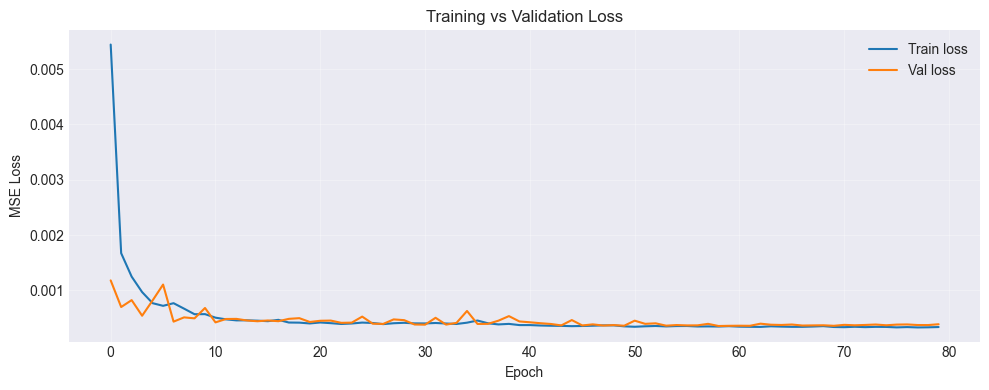

In [187]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

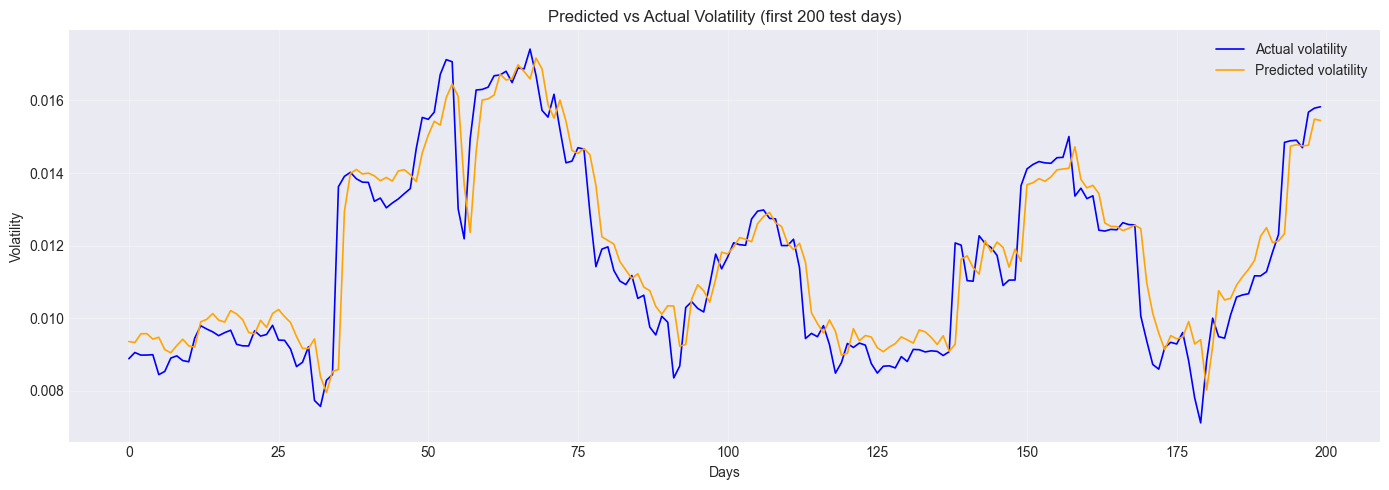

In [188]:
plt.figure(figsize=(14, 5))
plt.plot(true[:200],  label='Actual volatility',    color='blue',   linewidth=1.2)
plt.plot(preds[:200], label='Predicted volatility', color='orange', linewidth=1.2)
plt.title('Predicted vs Actual Volatility (first 200 test days)')
plt.xlabel('Days')
plt.ylabel('Volatility')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [189]:
# compare your model vs pure persistence
persistence_preds = true[:-1]   # today's vol as prediction for tomorrow
persistence_true  = true[1:]

persistence_rmse     = root_mean_squared_error(persistence_true, persistence_preds)
persistence_relative = persistence_rmse / persistence_true.mean()

print(f"Model         : {rmse/true.mean():.2%}")
print(f"Persistence   : {persistence_relative:.2%}")
print(f"Improvement   : {persistence_relative - rmse/true.mean():.2%}")

Model         : 9.61%
Persistence   : 9.67%
Improvement   : 0.06%


In [190]:
actual_change = true[1:] - true[:-1]
predicted_change = preds[1:] - true[:-1]

# 2. Check where the signs match (both up or both down)
correct_direction = np.sign(actual_change) == np.sign(predicted_change)

# 3. Calculate hit ratio
hit_ratio = np.mean(correct_direction)

print(f"Directional Hit Ratio: {hit_ratio:.2%}")

Directional Hit Ratio: 55.98%


In [179]:
# torch.save(model.state_dict(), 'model_weights4.pth')

# ──────── Fine-Tuning ──────────

In [ ]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')

In [ ]:
def train_trial(trial, tr_data, val_data, n_features):
    """
    Trains one model configuration suggested by Optuna.
    Returns best validation loss.
    """

    # ── suggest hyperparameters
    hidden_size   = trial.suggest_categorical('hidden_size',  [64, 128, 192, 256, 288, 320])
    num_layers    = trial.suggest_int('num_layers',           1, 4)
    dropout       = trial.suggest_float('dropout',            0.1, 0.5)
    learning_rate = trial.suggest_float('lr',                 1e-4, 5e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size',   [64, 128, 192, 256])
    patience      = trial.suggest_int('patience',             10, 25)
    W = trial.suggest_categorical('W',  [30, 40, 50, 60, 70, 80, 90, 100, 110])

    X_tr,  y_tr  = make_windows(tr_data,  W)
    X_val, y_val  = make_windows(val_data, W)
    scaler = fit_scaler(X_tr)
    X_tr_scaled  = apply_scaler(X_tr,  scaler)
    X_val_scaled   = apply_scaler(X_val, scaler)
 
    # ── dataloaders
    train_loader = DataLoader(StockDataset(X_tr_scaled,  y_tr),  batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(StockDataset(X_val_scaled, y_val), batch_size=batch_size, shuffle=False)
 
    # ── model
    model = StockLSTM(n_features, hidden_size, num_layers, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
 
    best_val_loss    = float('inf')
    patience_counter = 0
 
    for epoch in range(1, EPOCHS + 1):
 
        # train
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
 
        # validate
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_losses.append(criterion(model(X_batch), y_batch).item())
 
        val_loss = np.mean(val_losses)
        scheduler.step(val_loss)
 
        # early stopping
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
 
        # Optuna pruning — cuts unpromising trials early
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
 
    return best_val_loss
 
 
# ── Optuna objective ──────────────────────────────────────────────────────────
def make_objective(tr_data, val_data, n_features):
    def objective(trial):
        return train_trial(trial, tr_data, val_data, n_features)
    return objective

In [ ]:

# ── run Optuna study

N_TRIALS  = 100     # number of Optuna trials — increase to 100 if you have time
EPOCHS    = 100     # max epochs per trial — early stopping will cut most short
sampler = TPESampler(seed=42)      # TPE = Tree-structured Parzen Estimator
                                       # smarter than random search
pruner  = MedianPruner(
    n_startup_trials  = 5,         # don't prune first 5 trials
    n_warmup_steps    = 10,        # don't prune first 10 epochs of each trial
)
 
study = optuna.create_study(
    direction = 'minimize',        # minimize validation loss
    sampler   = sampler,
    pruner    = pruner,
    study_name= 'stock_lstm_tuning'
)
 
print(f"Starting Optuna search — {N_TRIALS} trials on {DEVICE}")
print("=" * 60)
 
study.optimize(
    make_objective(tr_data, val_data, n_features),
    n_trials  = N_TRIALS,
    show_progress_bar = True
)
 
# ── results
print("\n" + "=" * 60)
print("Best trial:")
print(f"  Val loss : {study.best_trial.value:.6f}")
print(f"  Params   :")
for k, v in study.best_trial.params.items():
    print(f"    {k:20s} : {v}")
 
# ── save study
joblib.dump(study, 'models/optuna_study.pkl')
print("\nStudy saved to models/optuna_study.pkl")

# ── plot results
try:
    import matplotlib.pyplot as plt
    from optuna.visualization.matplotlib import (
        plot_optimization_history,
        plot_param_importances,
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plt.sca(axes[0])
    plot_optimization_history(study)
    axes[0].set_title('Optimization history')

    plt.sca(axes[1])
    plot_param_importances(study)
    axes[1].set_title('Hyperparameter importance')

    plt.tight_layout()
    plt.savefig('models/optuna_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plots saved to models/optuna_results.png")
except Exception as e:
    print(f"Plotting skipped: {e}")

# the best parameters are:

window size (W) = 90

HIDDEN_SIZE = 256 

NUM_LAYERS = 2 

DROPOUT = 0.25588662208124313

LEARNING_RATE = 0.0014526827969336257

BATCH_SIZE = 64

PATIENCE = 21